In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

%matplotlib inline

In [337]:
df = pd.read_csv('vacancies.csv')

In [338]:
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.0,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.0,От 1 года до 3 лет,Москва,Полная занятость
2,20319022,NaN,NaN,Более 6 лет,Москва,Полная занятость
3,40619665,145000.0,215000.0,От 1 года до 3 лет,Нижний Новгород,Полная занятость
4,14675717,NaN,NaN,Более 6 лет,Москва,Полная занятость


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   vacancy_id       100000 non-null  int64  
 1   salary_from      68385 non-null   float64
 2   salary_to        69219 non-null   float64
 3   experience       100000 non-null  object 
 4   city             100000 non-null  object 
 5   employment_type  100000 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 4.6+ MB


In [340]:
df.describe()

,vacancy_id,salary_from,salary_to
count,1.000000e+05,6.838500e+04,6.921900e+04
mean,5.502163e+07,4.547105e+05,6.155720e+05
std,2.595831e+07,2.466358e+06,3.377744e+06
min,1.000028e+07,5.000000e+03,7.000000e+03
25%,3.250663e+07,8.500000e+04,1.100000e+05
50%,5.510610e+07,1.200000e+05,1.700000e+05
75%,7.749584e+07,1.900000e+05,2.600000e+05
max,9.999938e+07,5.950000e+07,8.950000e+07


Проверим дубликаты в vacanсy_id

In [341]:
df['vacancy_id'].nunique()

100000

Проверим на корректность заполнения данных

In [342]:
mask = df['salary_from'] > df['salary_to']
df[mask]

,vacancy_id,salary_from,salary_to,experience,city,employment_type
78,48429297,165000.0,130000.0,От 3 до 6 лет,Екатеринбург,Полная занятость
129,26376291,50000.0,45000.0,Нет опыта,Екатеринбург,Стажировка
200,51907364,355000.0,230000.0,От 1 года до 3 лет,Москва,Полная занятость
248,96998676,220000.0,160000.0,Более 6 лет,Новосибирск,Полная занятость
293,25983334,195000.0,150000.0,От 1 года до 3 лет,Москва,Полная занятость
...,...,...,...,...,...,...
99307,88048751,110000.0,80000.0,От 1 года до 3 лет,Казань,Полная занятость
99469,26281449,65000.0,60000.0,Нет опыта,Нижний Новгород,Полная занятость
99982,12506813,320000.0,200000.0,От 1 года до 3 лет,Москва,Полная занятость
99991,55437215,45000.0,40000.0,Нет опыта,Казань,Стажировка


Поменяем местами salary_from и salary_to, где нарушен порядок

In [343]:
df.loc[mask, ['salary_from', 'salary_to']] = (
    df.loc[mask, ['salary_to', 'salary_from']].to_numpy()
)

In [344]:
df[df['salary_from'] > df['salary_to']]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Проверим, есть ли отрицательные или "нулевые" зарплаты 

In [345]:
df[df['salary_from'] <= 0]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


In [346]:
df[df['salary_to'] <= 0]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Проверим, нет ли в "строковых" столбцах значений, которые "неправильно" написаны

In [347]:
df['experience'].unique()

array(['Нет опыта', 'От 1 года до 3 лет', 'Более 6 лет', 'От 3 до 6 лет'],
      dtype=object)

In [348]:
df['city'].unique()

array(['Екатеринбург', 'Москва', 'Нижний Новгород', 'Санкт-Петербург',
       'Новосибирск', 'Казань'], dtype=object)

In [349]:
df['employment_type'].unique()

array(['Удалённая работа', 'Полная занятость', 'Стажировка',
       'Частичная занятость'], dtype=object)

Удалим те записи, в которых нет ни salary_from, ни salary_to

In [350]:
df.dropna(subset=['salary_from', 'salary_to'], how='all', inplace=True)

In [351]:
df[['salary_from', 'salary_to']].isna().sum()

salary_from    6025
salary_to      5191
dtype: int64

In [352]:
df[df['salary_from'].isna() & df['salary_to'].isna()]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


Теперь попробуем восстановить пропущенные данные по зарплатам с помощью алгоритма KNN

In [353]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error as mae, mean_squared_error as mse

In [354]:
non_null_df = df[df['salary_from'].notna() & df['salary_to'].notna()]
non_null_df.shape

(63194, 6)

Достаточно данных, чтобы дополнить недостающие значения зарплаты

Обучим модель kNN

1. Сначала восстановим salary_from

Удалим выбросы c помощью интерквартильного интервала

In [355]:
Q1 = non_null_df['salary_from'].quantile(0.25)
Q3 = non_null_df['salary_from'].quantile(0.75)
IQR = Q3 - Q1

df_for_model = non_null_df[
    (non_null_df['salary_from'] >= Q1 - 1.5 * IQR) & (non_null_df['salary_from'] <= Q3 + 1.5 * IQR)
]

<Axes: >

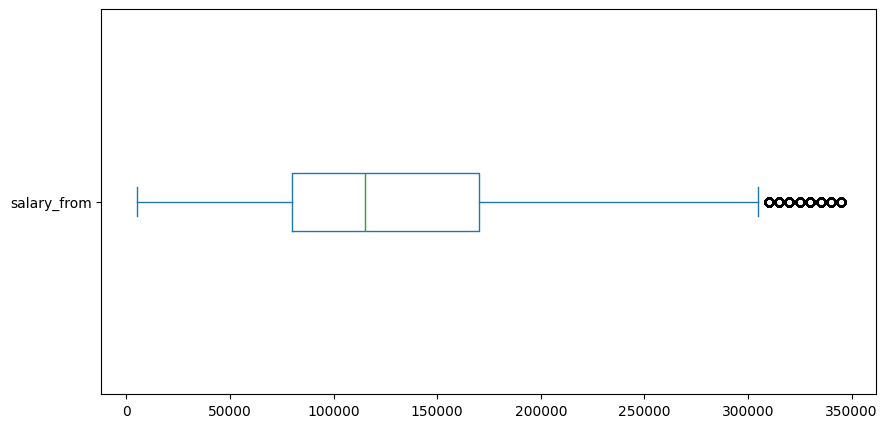

In [356]:
df_for_model['salary_from'].plot(kind='box', vert=False, figsize=(10, 5))

In [357]:
X, y = df_for_model.drop(columns=['vacancy_id', 'salary_from']), df_for_model[['salary_from']]

In [358]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [359]:
scaler = StandardScaler()
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [360]:
categorical_features = ['city', 'experience', 'employment_type']
numeric_features = ['salary_to']

encoded_train_features = encoder.fit_transform(X_train[categorical_features])
scaled_train_features = scaler.fit_transform(X_train[numeric_features])

encoded_test_features = encoder.transform(X_test[categorical_features])
scaled_test_features = scaler.transform(X_test[numeric_features])

feature_names = numeric_features + list(encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.DataFrame(
    np.hstack([scaled_train_features, encoded_train_features]),
    columns=feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    np.hstack([scaled_test_features, encoded_test_features]),
    columns=feature_names,
    index=X_test.index
)

In [361]:
best_mae = float('inf')
best_rmse = float('inf')
best_model = None

for k in range(1, 17):
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_encoded, y_train)

    prediction = knn.predict(X_test_encoded)

    current_mae = mae(y_test, prediction)
    current_rmse = mse(y_test, prediction) ** 0.5

    if current_mae < best_mae:
        best_mae = current_mae
        best_rmse = current_rmse
        best_model = knn

In [362]:
best_mae, best_rmse, best_model

(7515.76597303884, 10131.240427338169, KNeighborsRegressor(n_neighbors=15))

In [363]:
best_prediction = best_model.predict(X_test_encoded)

In [364]:
baseline_median_value = y_train.median()
baseline_mean_value = y_train.mean()

baseline_median_prediction = np.full(len(y_test), baseline_median_value)
baseline_mean_prediction = np.full(len(y_test), baseline_mean_value)

comparison = pd.DataFrame({
    'model': ['KNN', 'Baseline (median)', 'Baseline (mean)'],
    'MAE': [
        mae(y_test, best_prediction),
        mae(y_test, baseline_median_prediction),
        mae(y_test, baseline_mean_prediction)
    ],
    'RMSE': [
            mse(y_test, best_prediction) ** 0.5,
            mse(y_test, baseline_median_prediction) ** 0.5,
            mse(y_test, baseline_mean_prediction) ** 0.5
        ]
    })

comparison

,model,MAE,RMSE
0,KNN,7515.765973,10131.240427
1,Baseline (median),53088.194693,70792.128347
2,Baseline (mean),55040.830948,68667.642388


Попробуем заполнить пропуски в исходном датасете

In [365]:
missing_salary_from = df['salary_from'].isna() & df['salary_to'].notna()

X_missing = df.loc[missing_salary_from, categorical_features + numeric_features]
encoded_missing = encoder.transform(X_missing[categorical_features])
scaled_missing = scaler.transform(X_missing[numeric_features])

X_missing_encoded = pd.DataFrame(
    np.hstack([scaled_missing, encoded_missing]),
    columns=feature_names,
    index=X_missing.index
)

predicted_salary_from = best_model.predict(X_missing_encoded).ravel()
df.loc[missing_salary_from, 'salary_from'] = predicted_salary_from

df[['salary_from', 'salary_to']].isna().sum()

salary_from       0
salary_to      5191
dtype: int64

2. Повторим все то же самое для salary_to

In [366]:
Q1 = non_null_df['salary_to'].quantile(0.25)
Q3 = non_null_df['salary_to'].quantile(0.75)
IQR = Q3 - Q1

df_for_model = non_null_df[
    (non_null_df['salary_to'] >= Q1 - 1.5 * IQR) & (non_null_df['salary_to'] <= Q3 + 1.5 * IQR)
]

<Axes: >

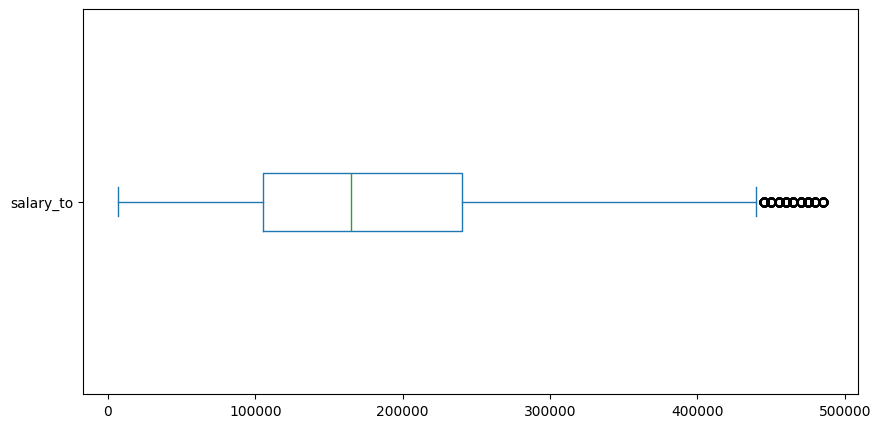

In [367]:
df_for_model['salary_to'].plot(kind='box', vert=False, figsize=(10, 5))

In [368]:
X, y = df_for_model.drop(columns=['vacancy_id', 'salary_to']), df_for_model[['salary_to']]

In [369]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

In [370]:
scaler = StandardScaler()
encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

In [371]:
categorical_features = ['city', 'experience', 'employment_type']
numeric_features = ['salary_from']

encoded_train_features = encoder.fit_transform(X_train[categorical_features])
scaled_train_features = scaler.fit_transform(X_train[numeric_features])

encoded_test_features = encoder.transform(X_test[categorical_features])
scaled_test_features = scaler.transform(X_test[numeric_features])

feature_names = numeric_features + list(encoder.get_feature_names_out(categorical_features))
X_train_encoded = pd.DataFrame(
    np.hstack([scaled_train_features, encoded_train_features]),
    columns=feature_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    np.hstack([scaled_test_features, encoded_test_features]),
    columns=feature_names,
    index=X_test.index
)

In [372]:
best_mae = float('inf')
best_rmse = float('inf')
best_model = None

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_encoded, y_train)

    prediction = knn.predict(X_test_encoded)

    current_mae = mae(y_test, prediction)
    current_rmse = mse(y_test, prediction) ** 0.5

    if current_mae < best_mae:
        best_mae = current_mae
        best_rmse = current_rmse
        best_model = knn

In [373]:
best_mae, best_rmse, best_model

(10494.785192441877, 14345.678824823737, KNeighborsRegressor(n_neighbors=11))

In [374]:
best_prediction = best_model.predict(X_test_encoded)

In [375]:
baseline_median_value = y_train.median()
baseline_mean_value = y_train.mean()

baseline_median_prediction = np.full(len(y_test), baseline_median_value)
baseline_mean_prediction = np.full(len(y_test), baseline_mean_value)

comparison = pd.DataFrame({
    'model': ['KNN', 'Baseline (median)', 'Baseline (mean)'],
    'MAE': [
        mae(y_test, best_prediction),
        mae(y_test, baseline_median_prediction),
        mae(y_test, baseline_mean_prediction)
    ],
    'RMSE': [
            mse(y_test, best_prediction) ** 0.5,
            mse(y_test, baseline_median_prediction) ** 0.5,
            mse(y_test, baseline_mean_prediction) ** 0.5
        ]
    })

comparison

,model,MAE,RMSE
0,KNN,10494.785192,14345.678825
1,Baseline (median),78030.346160,101157.546604
2,Baseline (mean),79598.885837,99424.870702


In [376]:
missing_salary_to = df['salary_to'].isna()

X_missing = df.loc[missing_salary_to, categorical_features + numeric_features]
encoded_missing = encoder.transform(X_missing[categorical_features])
scaled_missing = scaler.transform(X_missing[numeric_features])

X_missing_encoded = pd.DataFrame(
    np.hstack([scaled_missing, encoded_missing]),
    columns=feature_names,
    index=X_missing.index
)

predicted_salary_to = best_model.predict(X_missing_encoded).ravel()
df.loc[missing_salary_to, 'salary_to'] = predicted_salary_to

df[['salary_from', 'salary_to']].isna().sum()

salary_from    0
salary_to      0
dtype: int64

In [377]:
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.000000,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.000000,От 1 года до 3 лет,Москва,Полная занятость
3,40619665,145000.0,215000.000000,От 1 года до 3 лет,Нижний Новгород,Полная занятость
5,21241867,60000.0,70000.000000,Нет опыта,Москва,Стажировка
6,45942522,245000.0,352272.727273,От 1 года до 3 лет,Москва,Удалённая работа


In [383]:
df.to_csv('vacancies_filled.csv', index=False)

In [379]:
mask = df['salary_from'] > df['salary_to']

In [380]:
df.loc[mask, ['salary_from', 'salary_to']] = (
    df.loc[mask, ['salary_to', 'salary_from']].to_numpy()
)

In [382]:
df[df['salary_from'] > df['salary_to']]

,vacancy_id,salary_from,salary_to,experience,city,employment_type


A1. Посчитать основные описательные статистики в зависимости от опыта

In [2]:
df = pd.read_csv('vacancies_filled.csv')

In [4]:
df.head()

,vacancy_id,salary_from,salary_to,experience,city,employment_type
0,37351176,60000.0,70000.000000,Нет опыта,Екатеринбург,Удалённая работа
1,53503796,140000.0,210000.000000,От 1 года до 3 лет,Москва,Полная занятость
2,40619665,145000.0,215000.000000,От 1 года до 3 лет,Нижний Новгород,Полная занятость
3,21241867,60000.0,70000.000000,Нет опыта,Москва,Стажировка
4,45942522,245000.0,352272.727273,От 1 года до 3 лет,Москва,Удалённая работа


Вычислим для каждой вакансии среднее для дальнейших рассчетов

In [5]:
df['salary_mean'] = (df['salary_from'] + df['salary_to']) / 2

In [16]:
pt = pd.pivot_table(df, values='salary_mean', index=df['experience'], aggfunc=[
    np.mean,
    np.median,
    np.std,
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
])

C:\Users\egorl\AppData\Local\Temp\ipykernel_14720\433665296.py:1: FutureWarning: The provided callable <function mean at 0x0000026754AEFCE0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pt = pd.pivot_table(df, values='salary_mean', index=df['experience'], aggfunc=[
C:\Users\egorl\AppData\Local\Temp\ipykernel_14720\433665296.py:1: FutureWarning: The provided callable <function median at 0x0000026772D347C0> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  pt = pd.pivot_table(df, values='salary_mean', index=df['experience'], aggfunc=[
C:\Users\egorl\AppData\Local\Temp\ipykernel_14720\433665296.py:1: FutureWarning: The provided callable <function std at 0x0000026754AEFE20> is currently using DataFrameGroupBy.std. In a future versi

In [17]:
pt

mean         median           std    <lambda>  \
                      salary_mean    salary_mean   salary_mean salary_mean   
experience                                                                   
Более 6 лет         961984.332067  315000.000000  4.815447e+06    237500.0   
Нет опыта           231754.819480   79166.666667  1.124449e+06     62500.0   
От 1 года до 3 лет  532438.045551  150000.000000  2.880920e+06    110000.0   
От 3 до 6 лет       506016.990424  170000.000000  2.547241e+06    125000.0   

                                
                   salary_mean  
experience                      
Более 6 лет           402500.0  
Нет опыта              95000.0  
От 1 года до 3 лет    217500.0  
От 3 до 6 лет         225000.0

A2. Сравнить значения среднего и медианы

Если сравнивать значения среднего и медианы для каждой группы, то можно заметить, что среднее значение значительно больше медианы. Это может свидетельствовать о том, что в данных есть аномально большие зарплаты (либо они были в исходных данных, либо при импутации недостающих данных модель машинного обучения вероятно могла где-то неточно восстановить какую-то границу зарплатной вилки)

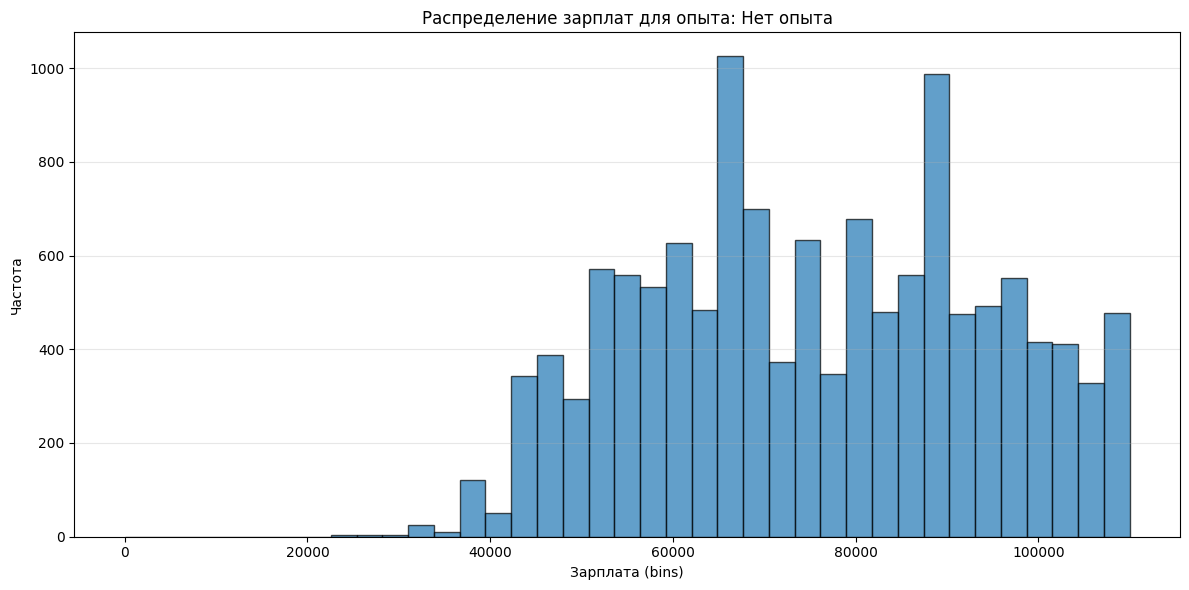

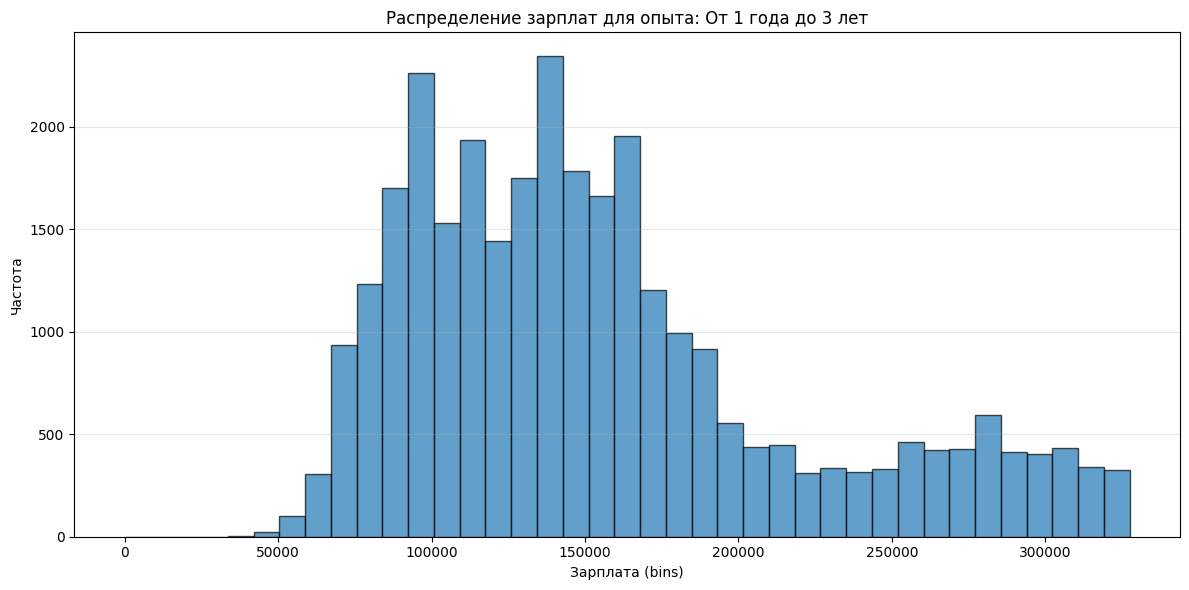

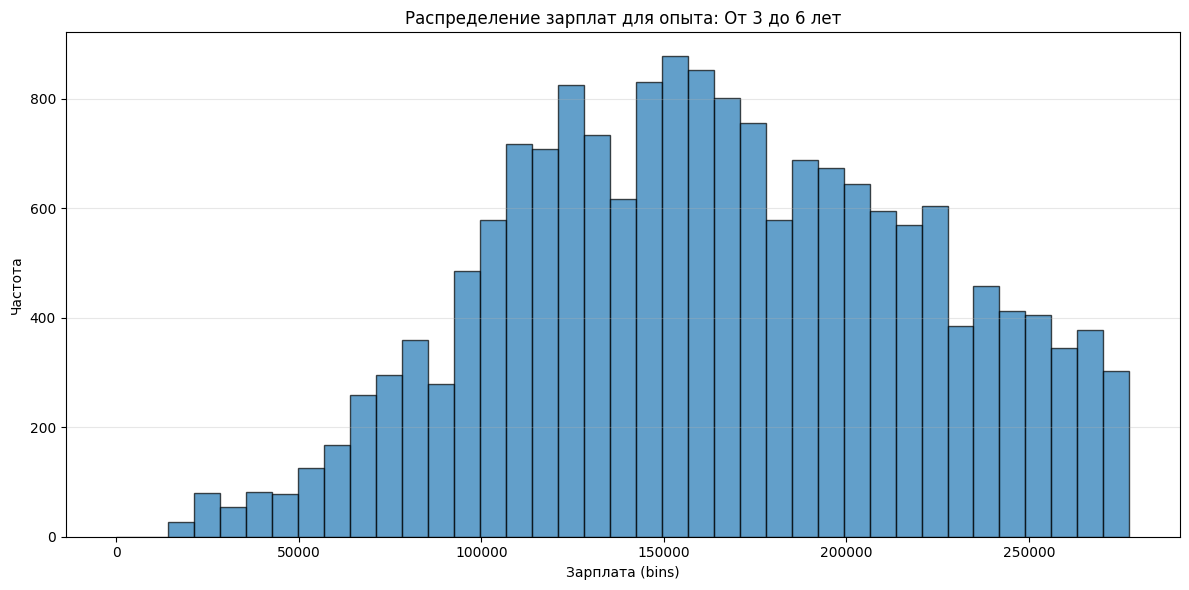

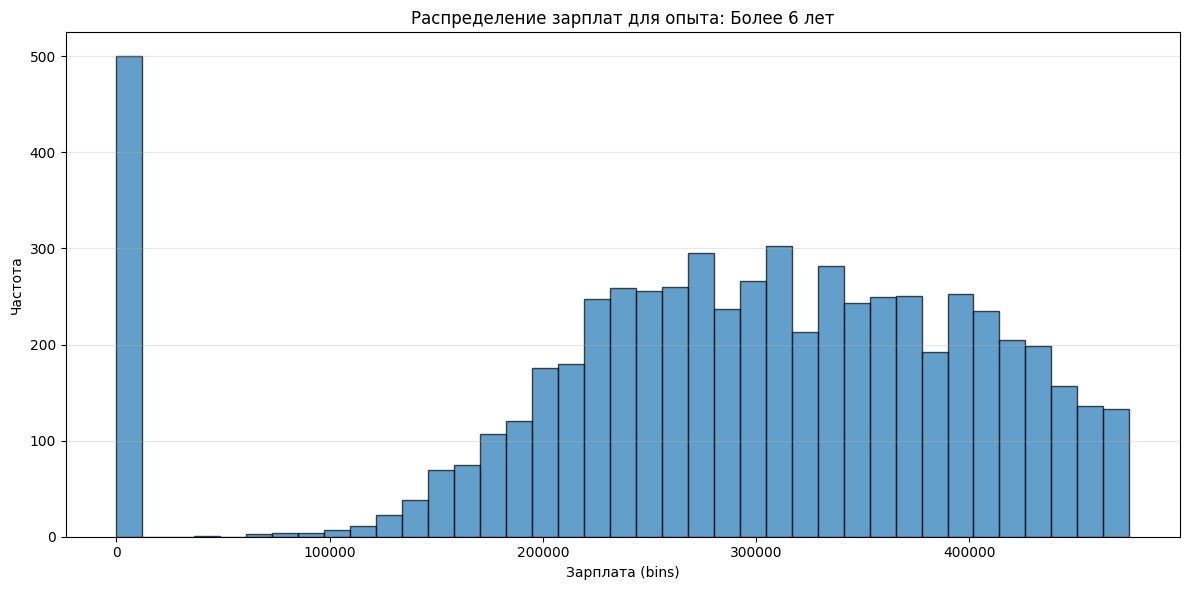

In [35]:
exp_list = ['Нет опыта', 'От 1 года до 3 лет', 'От 3 до 6 лет', 'Более 6 лет']

for exp in exp_list:
    salary_values = df[df['experience'] == exp]['salary_mean']
    salary_values = salary_values[salary_values <= salary_values.quantile(0.95)] # Удалим выбросы для построения гистограммы 

    bins = np.linspace(0, salary_values.quantile(0.95), 40)

    plt.figure(figsize=(12, 6))
    plt.hist(salary_values, bins=bins, edgecolor='black', alpha=0.7)
    plt.title(f'Распределение зарплат для опыта: {exp}')
    plt.xlabel('Зарплата (bins)')
    plt.ylabel('Частота')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


B1. Посчитать коэффициент ассиметрии

In [36]:
for exp in exp_list:
    salary_values = df[df['experience'] == exp]['salary_mean']

    n = len(salary_values)
    x_mean = salary_values.mean()
    x_std = salary_values.std()

    skwness = 1 / n * (np.sum((salary_values - x_mean) ** 3) / (x_std ** 3))

    print(f'Опыт: {exp}, Асимметрия: {skwness:.4f}')

Опыт: Нет опыта, Асимметрия: 7.6885
Опыт: От 1 года до 3 лет, Асимметрия: 11.7162
Опыт: От 3 до 6 лет, Асимметрия: 8.5136
Опыт: Более 6 лет, Асимметрия: 7.8373


Во всех группах наблюдается положительная асимметрия распределения зарплат, то есть присутствует длинный правый хвост высокооплачиваемых вакансий. Наиболее выраженная асимметрия наблюдается в группе специалистов с опытом от 1 до 3 лет (коэффициент 11.72). Это может быть связано с наличием небольшого числа вакансий с существенно более высокой зарплатой относительно основной массы предложений. Учитывая возможные ошибки парсинга исходных данных, экстремальные значения требуют дополнительной проверки.

B2. Объяснить почему результаты из A2 расходятся именно таким образом и как это связано со скошенностью

Во всех группах среднее значение существенно превышает медиану. Это связано с выраженной положительной асимметрией распределения зарплат, выявленной в B1: основная масса вакансий имеет относительно невысокие зарплаты, при этом небольшое количество вакансий имеет значительно более высокие значения и формирует длинный правый хвост. Такие значения сильнее влияют на среднее, чем на медиану. Наиболее выраженное расхождение наблюдается в группе «От 1 года до 3 лет», которая имеет максимальный коэффициент асимметрии (11.72). Поэтому для описания типичной зарплаты в данном наборе данных медиана является более устойчивой характеристикой, чем среднее.

B3. Посчитать разброс зарплат

In [39]:
spread = df.groupby('experience')['salary_mean'].agg(
    min='min',
    max='max',
    std='std',
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
)

spread['range'] = spread['max'] - spread['min']
spread['IQR'] = spread['q75'] - spread['q25']

spread.sort_values('IQR', ascending=False)[
    ['range', 'IQR', 'std']
]

,range,IQR,std
experience,,,
Более 6 лет,60744000.0,165000.0,4.815447e+06
От 1 года до 3 лет,73462500.0,107500.0,2.880920e+06
От 3 до 6 лет,37735000.0,100000.0,2.547241e+06
Нет опыта,13725000.0,32500.0,1.124449e+06


Для оценки разброса мы посчитали размах, межквартильный размах (IQR) и стандартное отклонение. Основной метрикой выбран IQR, поскольку распределения зарплат имеют выраженную правостороннюю асимметрию и содержат экстремально высокие значения. IQR менее чувствителен к выбросам и лучше характеризует разброс основной массы зарплат. Размах и стандартное отклонение приведены дополнительно для оценки влияния экстремальных значений.

По межквартильному размаху (IQR) наибольший разброс основной массы зарплат наблюдается в группе «Более 6 лет» — 165 тыс. ₽. При этом максимальный полный размах наблюдается в группе «От 1 года до 3 лет» и составляет 73,46 млн ₽. Значительное отличие размаха от IQR, а также большое стандартное отклонение (2,88 млн ₽) указывает на наличие экстремально высоких значений зарплат в этой группе. Это согласуется с результатами B1 и B2, где для группы «От 1 года до 3 лет» была выявлена наиболее выраженная правосторонняя асимметрия и наибольшее расхождение среднего и медианы.

Для кандидата это означает, что опыт работы сам по себе не позволяет точно определить будущую зарплату. Даже внутри одной категории опыта наблюдается значительный разброс. Поэтому при оценке ожидаемой зарплаты разумнее ориентироваться не только на среднее значение, но и на медиану и диапазон типичных зарплат.